# AET workflow (TERN STAC API)
Load items, point sample or reduce over an ROI, and plot a time series.


## Before you run
- Update placeholder values (`COLLECTION_ID`, dates, bounds, point coordinates) to match your data.
- Ensure auth is configured for protected assets (for example `.netrc` and/or GDAL config).
- Install optional dependencies required by this notebook's workflow (`odc-stac`, `rioxarray`, `geopandas`, plotting extras).
- Run cells from top to bottom so variables are initialized in order.


In [ ]:
from pathlib import Path

from tern_stac import TernStacClient, load_assets_as_time_series, plot_time_series

In [ ]:
# Fill in from your catalog values
COLLECTION_Q = "model-derived_aet__v2_1"
POINT_LON, POINT_LAT = 152.95, -27.47
POINT_CRS = "EPSG:4326"
REGION_BOUNDS = (
    119.914613,
    -23.561273,
    123.142615,
    -19.367202,
)  # (minx, miny, maxx, maxy)
REGION_BOUNDS_CRS = "EPSG:4326"


In [ ]:
Path("outputs").mkdir(exist_ok=True)

client = TernStacClient()
assets = []
search = client.collection_search(q=COLLECTION_Q, limit=5)
for i in search.collections():
    print(i.id)
    for a in i.assets:
        if "ETa" not in a or not a.endswith(".tif"):
            continue
        print(i.assets[a].href)
        assets.append(i.assets[a])


In [ ]:
ds = load_assets_as_time_series(
    assets,
    chunks=True,
    point=(POINT_LON, POINT_LAT),
    point_crs=POINT_CRS,
    to_numpy_nodata=True,
)
ds


In [ ]:
plot_time_series(
    ds,
    band_dim="band",
    figsize=(12, 6),
    compute=True,
    save_path="outputs/aet_point_time_series.png",
    title="AET Point Time Series",
)


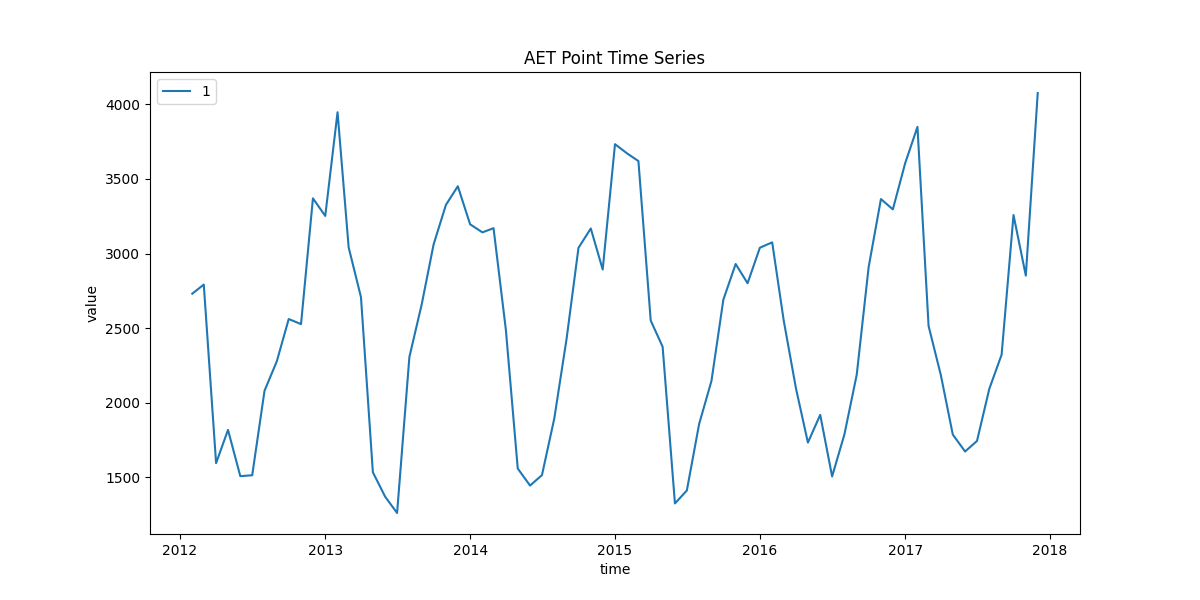

In [ ]:
ds = load_assets_as_time_series(
    assets,
    chunks=True,
    clip_bounds=REGION_BOUNDS,
    clip_bounds_crs=REGION_BOUNDS_CRS,
    to_numpy_nodata=True,
)
ds

In [ ]:
plot_time_series(
    ds,
    band_dim="band",
    figsize=(12, 6),
    compute=True,
    save_path="outputs/aet_roi_time_series.png",
    title="AET ROI avg Time Series",
)

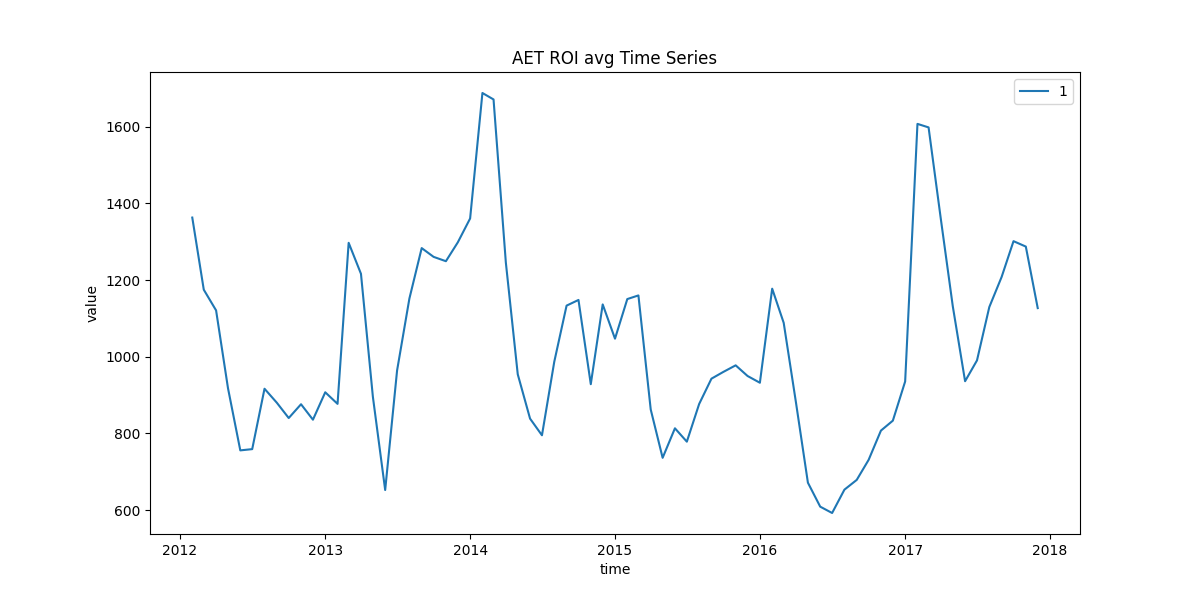